# **Notebook 01: Simulate DoA Estimation for ULA**

This notebook demonstrates the simulation of Direction of Arrival (DoA) estimation using a Uniform Linear Array (ULA) and the MUSIC (Multiple Signal Classification) algorithm.

## **1. Environment Setup and Parameters**
We begin by importing necessary libraries and setting core simulation parameters such as the number of samples, sampling frequency, and true source angles.

In [344]:
import sys
sys.path.insert(0, '/home/sajid/Work/DL-DoA')

In [345]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from simulations.signal_simulator import generate_composite_radio_signals
from tools.covariance_matrix import covariance_matrix, array_signal_model
from tools.doa_algorithms import estimate_doa_music
from tools.metrics import calculate_robust_rmse

In [346]:
# Parameters
num_samples = 1000
fs = 2000
n = np.random.randint(1, 10)
angles = np.arange(-60, 60, 1)
doa_angles = sorted(np.unique(np.random.choice(angles, n)).tolist())
num_sources = len(doa_angles)

random_seed = None

print("Number of Souces:", num_sources)
print("Source Angles:", doa_angles)

Number of Souces: 5
Source Angles: [-59, -29, -9, 22, 52]


## **2. Signal Generation**
Complex source signals are generated to simulate radio frequency emissions from five distinct sources.

In [347]:
# 1. Generate Complex Source Signals
signals, time_vector, _ = generate_composite_radio_signals(
    num_sources=num_sources,
    num_samples=num_samples,
    fs=fs,
    snr_db=None,
    random_seed=random_seed
)

#### **Visualizing Source Signals**
The absolute amplitude of each generated source signal is plotted over time.

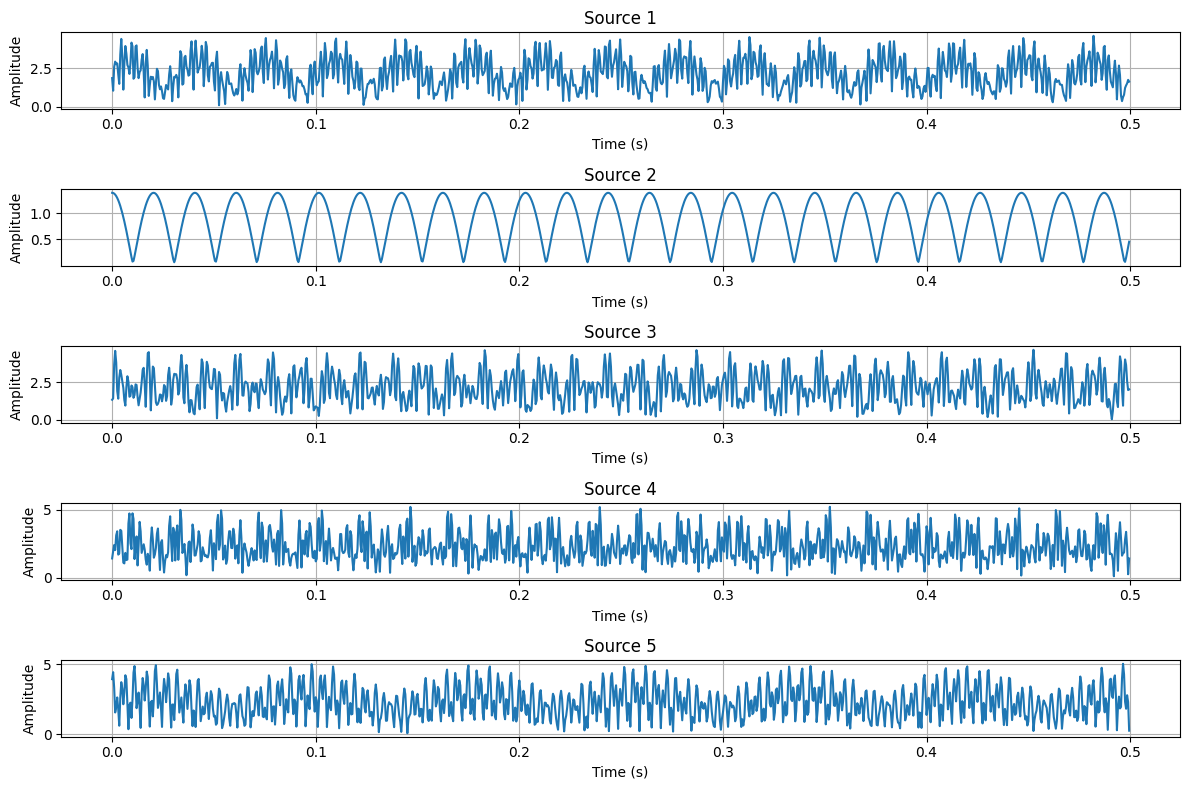

In [348]:
# Plot the generated signals in separate subplots
time_vector = np.arange(num_samples) / fs
plt.figure(figsize=(12, 8))
for i in range(num_sources):
    plt.subplot(num_sources, 1, i + 1)
    plt.plot(time_vector, np.abs(signals[i]))
    plt.title(f'Source {i + 1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
plt.tight_layout()
plt.show()

## **3. Array Geometry and Received Signal**
A Uniform Linear Array (ULA) is configured with 16 sensors spaced at half-wavelength intervals ($d=0.5$).

In [349]:
# 2. Setup Array Geometry (ULA)
d = 0.5
num_sensors = 16

sensor_positions = np.arange(num_sensors) * d
sensor_snr = 0
n_snapshots = 1000

# 3. Generate Received Array Signals
X, _, _ = array_signal_model(
    source_signals=signals,
    sensor_positions=sensor_positions,
    doa_angles=doa_angles,
    wavelength=1.0,
    snr_db=sensor_snr,
    n_snapshots=n_snapshots,
    random_seed=random_seed
)

print(f"Received signal shape: {X.shape}")

Received signal shape: (16, 1000)


## **4. Covariance Matrix Analysis**
The sample covariance matrix $R$ is computed from the received signal $X$ and visualized using a heatmap to show sensor correlations.

In [350]:
# 4. Compute Covariance Matrix
R = covariance_matrix(X)

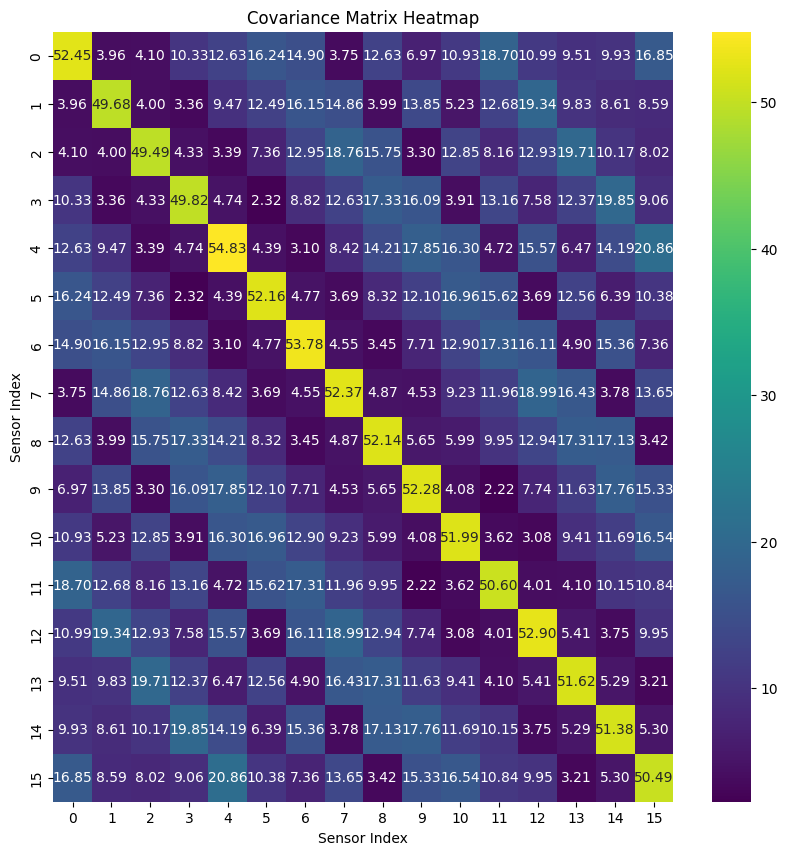

In [351]:
# Plot Heatmap of the covariance matrix
plt.figure(figsize=(10, 10))
sns.heatmap(np.abs(R), annot=True, fmt=".2f", cmap="viridis")
plt.title("Covariance Matrix Heatmap")
plt.xlabel("Sensor Index")
plt.ylabel("Sensor Index")
plt.show()

## **5. DoA Estimation using MUSIC**
The MUSIC algorithm scans the physical field of view from $-90^\circ$ to $90^\circ$ to estimate the incoming angles of the signals.

In [352]:
# 5. Estimate DOA
estimated_angles, spectrum, angle_grid = estimate_doa_music(
    Rxx=R,
    num_sources=num_sources,
    sensor_positions=sensor_positions,
    n_snapshots=n_snapshots,
    wavelength=1.0,
    scan_angles=np.linspace(-90, 90, 1801)
)

print("Estimation Complete!")

Estimation Complete!


#### **MUSIC Spectrum Plot**
The spectrum shows sharp peaks at the estimated angles, aligning closely with the actual DoA markers.

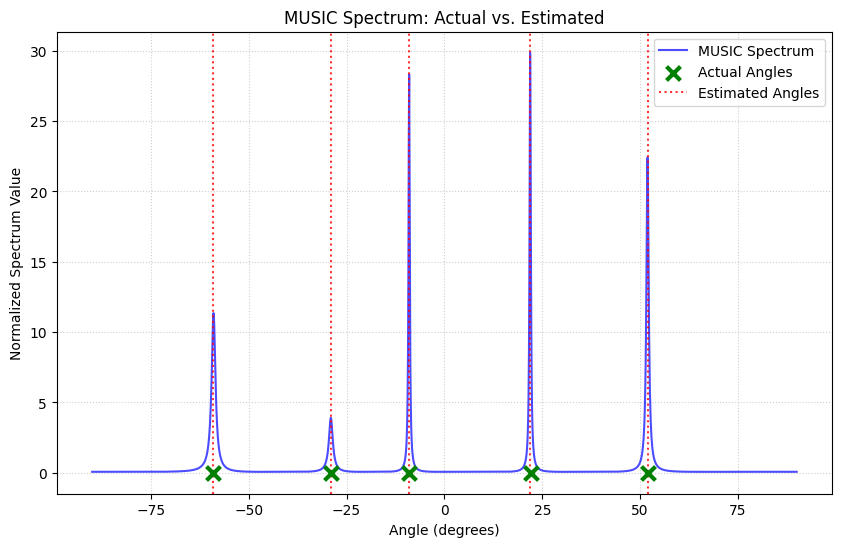

In [353]:
plt.figure(figsize=(10, 6))
plt.plot(angle_grid, spectrum, label='MUSIC Spectrum', color='b', alpha=0.7)

# Mark actual DOA angles to compare with estimated angles
for i, angle in enumerate(doa_angles):
    label = 'Actual Angles' if i == 0 else ""
    plt.scatter(angle, 0, color='g', marker='x', s=100, 
                linewidths=3, label=label, zorder=6)

# Mark estimated DOA angles
for i, angle in enumerate(estimated_angles):
    label = 'Estimated Angles' if i == 0 else ""
    plt.axvline(x=angle, color='r', linestyle=':', linewidth=1.5, 
                label=label, zorder=4, alpha=0.8)

plt.title('MUSIC Spectrum: Actual vs. Estimated')
plt.xlabel('Angle (degrees)')
plt.ylabel('Normalized Spectrum Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## **6. Performance Evaluation**
The accuracy of the estimation is measured using the Root Mean Square Error (RMSE).

In [354]:
# RMSE Calculation
rmse = calculate_robust_rmse(estimated_angles, doa_angles)

print(f"Number of sources        : {num_sources}")
print(f"Number of Estimated DOAs : {len(estimated_angles)}\n")
print(f"True DOA angles         : {doa_angles}")
print(f"Estimated DOA angles    : {estimated_angles.tolist()}\n")
print(f"Robust RMSE between estimated and true DOA angles: {rmse:.2f} degrees")

Number of sources        : 5
Number of Estimated DOAs : 5

True DOA angles         : [-59, -29, -9, 22, 52]
Estimated DOA angles    : [-59.0, -29.0, -9.0, 21.900000000000006, 51.900000000000006]

Robust RMSE between estimated and true DOA angles: 0.06 degrees
